<a href="https://colab.research.google.com/github/edik06031-rgb/DTA_2026/blob/main/HW/practice_stat_tests_17_06.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 📊 Статистичні тести: практикум

**Тривалість:** ~4 години · бібліотека `scipy.stats`

---

Цей практикум закріплює лекцію про p-значення та статистичну значущість. Він влаштований так:

- 🟦 **Теорія** — короткий блок перед кожним тестом: *коли* його обирати, *чому*, *як читати результат*.
- ✏️ **Завдання (код)** — ви пишете код, що проводить тест.
- 💬 **Інтерпретація** — ви **своїми словами** пояснюєте, що означає результат. Це найважливіша частина! Аналітик, який уміє порахувати p-значення, але не вміє його пояснити — це лише калькулятор.

## Як працювати
1. Читайте теоретичний блок.
2. Виконуйте завдання на код (Shift+Enter).
3. На кожне питання інтерпретації відповідайте **повним реченням людською мовою** — так, ніби пояснюєте керівнику без технічної освіти.

## Загальне правило
- `p < 0.05` → статистично значущо → відхиляємо H₀
- `p ≥ 0.05` → не значущо → не відхиляємо H₀

> 💡 Тримайте поруч шпаргалку вибору тесту з лекції. Половина завдань — про те, щоб **обрати правильний тест**.

---

## Підготовка

Запустіть цю клітинку. Ми працюємо з двома наборами даних:
- **`shop_customers.csv`** — 500 клієнтів інтернет-магазину
- **`ab_test.csv`** — результати A/B-тесту (8000 сесій)


In [ ]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt

df = pd.read_csv("shop_customers.csv")
ab = pd.read_csv("ab_test.csv")

print("Клієнти:", df.shape)
print("A/B тест:", ab.shape)
df.head()

Клієнти: (500, 11)
A/B тест: (8000, 3)


,customer_id,gender,age,country,channel,device,spend,session_min,sat_before,sat_after,purchased
0,1001,Ч,23,Німеччина,Реклама,Desktop,997.11,22.2,6,7,Так
1,1002,Ч,38,Україна,Органіка,Desktop,510.09,19.8,5,8,Ні
2,1003,Ч,20,Україна,Соцмережі,Desktop,789.71,21.0,7,8,Ні
3,1004,Ч,40,Німеччина,Соцмережі,Desktop,1041.02,17.4,8,9,Ні
4,1005,Ч,18,Україна,Реклама,Desktop,944.34,23.5,6,7,Ні


### Опис даних `shop_customers.csv`

| Стовпець | Опис | Тип |
|---|---|---|
| `customer_id` | ID клієнта | — |
| `gender` | Стать (Ч/Ж) | категоріальний |
| `age` | Вік | числовий |
| `country` | Країна | категоріальний |
| `channel` | Канал залучення (Органіка/Реклама/Соцмережі) | категоріальний |
| `device` | Пристрій (Mobile/Desktop) | категоріальний |
| `spend` | Витрати клієнта, грн | числовий |
| `session_min` | Час на сайті, хв | числовий |
| `sat_before` | Задоволеність ДО редизайну (1-10) | числовий |
| `sat_after` | Задоволеність ПІСЛЯ редизайну (1-10) | числовий |
| `purchased` | Чи зробив покупку (Так/Ні) | категоріальний |

Спочатку завжди корисно роздивитись дані.

#### ✏️ Завдання 1 (код)

Виведіть основну статистику по числових стовпцях (підказка: метод `.describe()`).

In [ ]:
# Завдання 1:
summary_stats = df.describe().round(2)
print(summary_stats)

       customer_id     age    spend  session_min  sat_before  sat_after
count       500.00  500.00   500.00       500.00      500.00     500.00
mean       1250.50   34.65   845.02        20.74        6.54       7.14
std         144.48   10.96   333.46        10.53        1.52       1.83
min        1001.00   18.00    50.00         1.00        2.00       1.00
25%        1125.75   26.00   612.63        13.10        6.00       6.00
50%        1250.50   34.00   834.75        20.85        7.00       7.00
75%        1375.25   41.25  1070.40        27.40        8.00       9.00
max        1500.00   69.00  1952.02        52.20       10.00      10.00


#### ✏️ Завдання 2 (код)

Скільки клієнтів у кожному каналі залучення? (підказка: `.value_counts()` на стовпці `channel`)

In [ ]:
# Завдання 2:
channel_counts = df['channel'].value_counts()

print('Кількість клієнтів по каналах залучення:')
print(channel_counts)

Кількість клієнтів по каналах залучення:
channel
Органіка     174
Соцмережі    167
Реклама      159
Name: count, dtype: int64


---
# Розділ 1. Одновибірковий t-тест

## 🟦 Теорія: коли і чому

**Коли обирати:** коли у вас є **одна** група числових даних, і ви хочете порівняти її **середнє** з якимось **фіксованим, наперед відомим числом** (ціль, норматив, заявлене значення).

**Чому саме він:** ми перевіряємо, чи відхилення нашого середнього від цільового числа реальне, чи це випадковість вибірки.

**Гіпотези:**
- H₀: середнє = цільове число
- H₁: середнє ≠ цільове число

**Функція:** `stats.ttest_1samp(дані, цільове_число)`

**Як читати:** дивимось на p-значення. Якщо `p < 0.05` — середнє значущо відрізняється від цільового.

**Приклад із життя:** виробник заявляє, що пакет чипсів важить 100 г. Ви зважили 50 пакетів. Чи справді середня вага = 100 г, чи вас обманюють?

**Сценарій:** маркетолог стверджує, що середній час на сайті становить 20 хвилин. Перевіримо це.

#### ✏️ Завдання 3 (код)

Порахуйте фактичний середній `session_min`. Потім проведіть одновибірковий t-тест, щоб перевірити, чи відрізняється він від 20. Виведіть t-статистику та p-значення.

In [ ]:
# Завдання 3:
from scipy.stats import ttest_1samp

# Фактичний середній час сесії
mean_session = df['session_min'].mean()

# H0: середній час сесії = 20 хв
t_stat, p_value = ttest_1samp(df['session_min'].dropna(), popmean=20)

print(f'Середній session_min: {mean_session:.2f}')
print(f't-статистика: {t_stat:.4f}')
print(f'p-значення: {p_value:.4f}')

Середній session_min: 20.74
t-статистика: 1.5698
p-значення: 0.1171


#### 💬 Інтерпретація 1

Чи відрізняється середній час на сайті від заявлених 20 хвилин? Сформулюйте висновок для маркетолога: він мав рацію чи ні? Чому ви так вважаєте (спирайтесь на p-значення)?

*(Напишіть відповідь у наступній клітинці. Двічі клацніть, щоб редагувати.)*

**Ваша відповідь:**

*.Було проведено одновибірковий t-тест для перевірки твердження маркетолога, що середній час перебування користувача на сайті становить 20 хвилин.

Фактичний середній час сесії склав 20.74 хвилини, а отримане p-значення = 0.1171.

Оскільки p-value > 0.05, ми не відхиляємо нульову гіпотезу. Це означає, що різниця між фактичним середнім часом (20.74 хв) та заявленими 20 хвилинами не є статистично значущою.

Висновок для маркетолога: наявні дані не дають підстав стверджувати, що середній час перебування на сайті відрізняється від 20 хвилин. Отже, твердження маркетолога узгоджується з даними, і його оцінку можна вважати обґрунтованою...*

**Другий сценарій:** керівник вважає, що середні витрати клієнта = 850 грн.

#### ✏️ Завдання 4 (код)

Перевірте за допомогою одновибіркового t-тесту, чи середні витрати (`spend`) відрізняються від 850 грн.

In [ ]:
# Завдання 4:
from scipy.stats import ttest_1samp

mean_spend = df['spend'].mean()

t_stat, p_value = ttest_1samp(
    df['spend'].dropna(),
    popmean=850
)

print(f'Середні витрати: {mean_spend:.2f}')
print(f't-статистика: {t_stat:.4f}')
print(f'p-значення: {p_value:.4f}')

Середні витрати: 845.02
t-статистика: -0.3342
p-значення: 0.7384


#### 💬 Інтерпретація 2

Що показав тест? Чи можна сказати, що середні витрати дорівнюють 850 грн? Поясніть, чому тут ми НЕ відхиляємо нульову гіпотезу (зверніть увагу на формулювання: чи це означає, що середнє точно дорівнює 850?).

*(Напишіть відповідь у наступній клітинці. Двічі клацніть, щоб редагувати.)*

**Ваша відповідь:**

*Було проведено одновибірковий t-тест для перевірки твердження керівника, що середні витрати клієнта становлять 850 грн.

Фактичні середні витрати склали 845.02 грн, а отримане p-значення = 0.7384.

Оскільки p-value значно більше 0.05, ми не відхиляємо нульову гіпотезу. Це означає, що різниця між середнім значенням у вибірці (845.02 грн) та 850 грн є статистично незначущою і може бути пояснена випадковими коливаннями даних.

Важливо розуміти, що не відхилити нульову гіпотезу не означає довести, що середні витрати точно дорівнюють 850 грн. Це лише означає, що на основі наявної вибірки немає достатніх статистичних доказів стверджувати, що середні витрати відрізняються від 850 грн.

Отже, дані узгоджуються з припущенням керівника, і твердження про середні витрати на рівні 850 грн можна вважати обґрунтованим.*

---
# Розділ 2. Двовибірковий t-тест (незалежні групи)

## 🟦 Теорія: коли і чому

**Коли обирати:** коли ви порівнюєте **середні двох РІЗНИХ, незалежних груп** числових даних.

**Чому саме він:** хочемо дізнатись, чи різниця між групами реальна, чи могла виникнути випадково.

**Ключова умова — групи НЕЗАЛЕЖНІ:** різні люди в кожній групі (на відміну від парного тесту, де ті самі люди двічі).

**Гіпотези:**
- H₀: середнє групи 1 = середнє групи 2
- H₁: вони відрізняються

**Функція:** `stats.ttest_ind(група1, група2)`

**Приклад із життя:** чи відрізняється середня зарплата у двох відділах? Чи витрачають більше клієнти з міста А порівняно з містом Б?

**Сценарій:** чи витрачають клієнти з мобільних більше, ніж з десктопу?

#### ✏️ Завдання 5 (код)

Розділіть `spend` на дві групи за `device` (Mobile та Desktop). Виведіть середнє кожної групи і проведіть двовибірковий t-тест.

In [ ]:
# Завдання 5:
mobile = df[df['device'] == 'Mobile']['spend'].dropna()
desktop = df[df['device'] == 'Desktop']['spend'].dropna()

print(f'Середні витрати Mobile: {mobile.mean():.2f}')
print(f'Середні витрати Desktop: {desktop.mean():.2f}')

t_stat, p_value = stats.ttest_ind(mobile, desktop)
print(f't-статистика: {t_stat:.4f}')
print(f'p-значення: {p_value:.4f}')


Середні витрати Mobile: 835.21
Середні витрати Desktop: 861.16
t-статистика: -0.8436
p-значення: 0.3993


#### 💬 Інтерпретація 3

Чи є значуща різниця у витратах між Mobile та Desktop? Якби ви були аналітиком, чи порадили б компанії інвестувати в мобільну версію на основі цього результату?

*(Напишіть відповідь у наступній клітинці. Двічі клацніть, щоб редагувати.)*

**Ваша відповідь:**

*Було проведено двовибірковий t-тест для порівняння середніх витрат клієнтів, які користуються Mobile та Desktop.

Середні витрати Mobile склали 835.21 грн, Desktop — 861.16 грн. Отримане p-значення = 0.3993.

Оскільки p-value > 0.05, ми не відхиляємо нульову гіпотезу. Це означає, що різниця у витратах між мобільними та десктопними клієнтами (близько 26 грн) статистично незначуща і найімовірніше пояснюється випадковістю вибірки, а не реальною відмінністю в поведінці користувачів.

Як аналітик, я б НЕ радив інвестувати в мобільну версію на основі лише цього результату — дані не підтверджують, що мобільні користувачі витрачають більше (чи менше). Якщо є інші бізнес-причини для інвестицій у мобільну версію (наприклад, зростання частки мобільного трафіку чи зручність користування), їх варто шукати окремо, а не обґрунтовувати різницею у витратах, якої статистично не виявлено.*


**Сценарій:** чи різниться час на сайті залежно від статі?

#### ✏️ Завдання 6 (код)

Порівняйте `session_min` між чоловіками та жінками за допомогою двовибіркового t-тесту.

In [ ]:
# Завдання 6:
male = df[df['gender'] == 'Ч']['session_min'].dropna()
female = df[df['gender'] == 'Ж']['session_min'].dropna()

print(f'Середній session_min (чоловіки): {male.mean():.2f}')
print(f'Середній session_min (жінки): {female.mean():.2f}')

t_stat, p_value = stats.ttest_ind(male, female)
print(f't-статистика: {t_stat:.4f}')
print(f'p-значення: {p_value:.4f}')


Середній session_min (чоловіки): 20.85
Середній session_min (жінки): 20.63
t-статистика: 0.2324
p-значення: 0.8163


#### 💬 Інтерпретація 4

Сформулюйте висновок. Якщо різниця не значуща — що це означає на практиці для команди маркетингу?

*(Напишіть відповідь у наступній клітинці. Двічі клацніть, щоб редагувати.)*

**Ваша відповідь:**

*Було проведено двовибірковий t-тест для порівняння часу на сайті між чоловіками (середнє 20.85 хв) та жінками (середнє 20.63 хв). Отримане p-значення = 0.8163.

Оскільки p-value значно більше 0.05, ми не відхиляємо нульову гіпотезу: статистично значущої різниці в часі на сайті між чоловіками і жінками немає.

На практиці для команди маркетингу це означає, що стать клієнта не варто використовувати як критерій для персоналізації контенту чи реклами з огляду на тривалість сесії — обидві статі проводять на сайті приблизно однаковий час, тож сегментація за статтю для цієї метрики не дасть додаткової цінності.*


---
# Розділ 3. Парний t-тест

## 🟦 Теорія: коли і чому

**Коли обирати:** коли ви маєте **два виміри в ОДНИХ І ТИХ САМИХ обʼєктів** — типово «до і після» якоїсь зміни.

**Чому саме він (а не звичайний t-тест):** виміри пов'язані (той самий клієнт до і після). Парний тест враховує цей зв'язок і тому **потужніший** — він краще виявляє реальні зміни.

**Гіпотези:**
- H₀: середня різниця (після − до) = 0 (зміни немає)
- H₁: середня різниця ≠ 0 (зміна є)

**Функція:** `stats.ttest_rel(до, після)`

**Приклад із життя:** вага пацієнтів до і після дієти. Продуктивність працівників до і після тренінгу. Бали студентів до і після курсу.

> ⚠️ Головна підказка для вибору: якщо ви бачите слова «до/після», «був/став», «той самий обʼєкт двічі» — це парний тест.

**Сценарій:** компанія зробила редизайн сайту і виміряла задоволеність тих самих клієнтів до (`sat_before`) і після (`sat_after`).

#### ✏️ Завдання 7 (код)

Проведіть парний t-тест, щоб перевірити, чи змінилася задоволеність клієнтів після редизайну. Виведіть середні значення до і після, а також p-значення.

In [ ]:
# Завдання 7:
mean_before = df['sat_before'].mean()
mean_after = df['sat_after'].mean()

t_stat, p_value = stats.ttest_rel(df['sat_before'], df['sat_after'])

print(f'Середня задоволеність ДО: {mean_before:.3f}')
print(f'Середня задоволеність ПІСЛЯ: {mean_after:.3f}')
print(f't-статистика: {t_stat:.4f}')
print(f'p-значення: {p_value:.4e}')


Середня задоволеність ДО: 6.536
Середня задоволеність ПІСЛЯ: 7.138
t-статистика: -11.3026
p-значення: 1.5708e-26


#### 💬 Інтерпретація 5

Чи спрацював редизайн? Поясніть, чому тут доречний саме ПАРНИЙ тест, а не звичайний двовибірковий. Що було б не так, якби ми використали `ttest_ind`?

*(Напишіть відповідь у наступній клітинці. Двічі клацніть, щоб редагувати.)*

**Ваша відповідь:**

*Було проведено парний t-тест для порівняння задоволеності тих самих клієнтів до (6.536) і після (7.138) редизайну сайту. Отримане p-значення дуже мале (≈1.57×10⁻²⁶, тобто набагато менше 0.05).

Ми відхиляємо нульову гіпотезу: редизайн справді призвів до статистично значущого зростання задоволеності клієнтів (приблизно на 0.6 бала за шкалою 1-10).

Парний тест доречний тому, що задоволеність вимірювали у одних і тих самих клієнтів двічі (до і після), тобто виміри пов'язані між собою — у кожного клієнта своя «базова» схильність оцінювати високо чи низько. Парний тест враховує цей зв'язок, віднімаючи «до» від «після» для кожної людини окремо, і тому усуває зайву варіацію між людьми, залишаючи лише варіацію самої зміни.

Якби ми використали звичайний `ttest_ind`, то трактували б «до» і «після» як дві незалежні групи різних людей, ігноруючи факт, що це ті самі клієнти. Це додало б зайвий "шум" від міжособистісних відмінностей у вибірку, тест став би менш потужним (менш чутливим до реальної зміни), і ми могли б навіть не виявити значущого ефекту, який насправді є.*


---
# Розділ 4. ANOVA (дисперсійний аналіз)

## 🟦 Теорія: коли і чому

**Коли обирати:** коли ви порівнюєте середні **ТРЬОХ або більше груп** числових даних.

**Чому не кілька t-тестів:** якби ми порівнювали групи попарно багатьма t-тестами, ми б накопичили помилки I роду (згадайте проблему множинних порівнянь!). ANOVA перевіряє все одним тестом.

**Гіпотези:**
- H₀: середні ВСІХ груп однакові
- H₁: принаймні одна група відрізняється

**Функція:** `stats.f_oneway(група1, група2, група3, ...)`

**Важливе обмеження:** ANOVA каже, що різниця Є, але не каже, **між якими саме** групами. Для цього потрібні додаткові (post-hoc) тести.

**Приклад із життя:** чи відрізняється врожайність при трьох різних добривах? Чи різний середній дохід у чотирьох регіонах?

**Сценарій:** чи залежать витрати клієнта від каналу залучення (Органіка / Реклама / Соцмережі)?

#### ✏️ Завдання 8 (код)

Виведіть середні `spend` для кожного каналу. Потім проведіть ANOVA, щоб перевірити, чи є значуща різниця між каналами. (Підказка: створіть список груп через цикл або вручну, потім передайте їх у `f_oneway`.)

In [ ]:
# Завдання 8:
print('Середні витрати по каналах:')
print(df.groupby('channel')['spend'].mean().round(2))

groups = [g['spend'].dropna().values for _, g in df.groupby('channel')]
f_stat, p_value = stats.f_oneway(*groups)

print(f'\nF-статистика: {f_stat:.4f}')
print(f'p-значення: {p_value:.4e}')


Середні витрати по каналах:
channel
Органіка      791.28
Реклама      1057.87
Соцмережі     698.35
Name: spend, dtype: float64

F-статистика: 63.5400
p-значення: 2.6753e-25


#### 💬 Інтерпретація 6

Чи відрізняються канали за витратами? Який канал виглядає найприбутковішим? Чому на основі лише ANOVA ми НЕ можемо точно сказати, що, наприклад, Реклама значущо краща за Органіку?

*(Напишіть відповідь у наступній клітинці. Двічі клацніть, щоб редагувати.)*

**Ваша відповідь:**

*Середні витрати по каналах: Реклама — 1057.87 грн, Органіка — 791.28 грн, Соцмережі — 698.35 грн. ANOVA дала F = 63.54, p ≈ 2.68×10⁻²⁵ (набагато менше 0.05).

Ми відхиляємо нульову гіпотезу: канали залучення значущо відрізняються за середніми витратами клієнтів. На перший погляд найприбутковішим виглядає канал «Реклама».

Проте ANOVA лише каже, що ХОЧА Б ОДНА пара груп відрізняється — вона не вказує, яка саме пара (наприклад, чи саме «Реклама vs Органіка» значуща, чи різниця тримається лише на парі «Реклама vs Соцмережі»). Щоб точно стверджувати, що Реклама значущо краща за Органіку, потрібен окремий попарний (post-hoc) тест.


**Сценарій:** чи залежить час на сайті (`session_min`) від країни клієнта?

#### ✏️ Завдання 9 (код)

Проведіть ANOVA для `session_min` за трьома країнами (`country`).

In [ ]:
# Завдання 9:
print('Середній session_min по країнах:')
print(df.groupby('country')['session_min'].mean().round(2))

groups = [g['session_min'].dropna().values for _, g in df.groupby('country')]
f_stat, p_value = stats.f_oneway(*groups)

print(f'\nF-статистика: {f_stat:.4f}')
print(f'p-значення: {p_value:.4f}')


Середній session_min по країнах:
country
Німеччина    21.29
Польща       21.17
Україна      20.29
Name: session_min, dtype: float64

F-статистика: 0.4930
p-значення: 0.6111


#### 💬 Інтерпретація 7

Що показав результат? Сформулюйте висновок про звʼязок країни і часу на сайті.

*(Напишіть відповідь у наступній клітинці. Двічі клацніть, щоб редагувати.)*

**Ваша відповідь:**

*Середній час на сайті по країнах майже однаковий: Німеччина — 21.29 хв, Польща — 21.17 хв, Україна — 20.29 хв. ANOVA дала F = 0.493, p = 0.611.

Оскільки p-value значно більше 0.05, ми не відхиляємо нульову гіпотезу: статистично значущого звʼязку між країною клієнта та часом на сайті не виявлено. Невеликі відмінності в середніх значеннях, які ми бачимо в таблиці, найімовірніше є наслідком випадкових коливань вибірки, а не реальної різниці в поведінці клієнтів із різних країн.*


---
# Розділ 5. Хі-квадрат (χ²)

## 🟦 Теорія: коли і чому

**Коли обирати:** коли обидві змінні **категоріальні**, і ви хочете перевірити, чи є між ними **звʼязок**.

**Чому саме він:** t-тест і ANOVA працюють із числами (середніми). Коли даних немає що усереднювати (категорії на кшталт «купив/не купив», «місто», «колір»), використовують хі-квадрат на основі **частот**.

**Гіпотези:**
- H₀: змінні незалежні (звʼязку немає)
- H₁: змінні повʼязані

**Як проводити (два кроки):**
1. Побудувати таблицю спряженості: `pd.crosstab(змінна1, змінна2)`
2. Передати її у `stats.chi2_contingency(таблиця)` — повертає chi2, p, dof, expected

**Приклад із життя:** чи повʼязана стать із вибором категорії товару? Чи залежить рішення про покупку від кольору кнопки (це і є A/B-тест для конверсій!)?

**Сценарій:** чи повʼязаний канал залучення (`channel`) із фактом покупки (`purchased`)?

#### ✏️ Завдання 10 (код)

Побудуйте таблицю спряженості між `channel` та `purchased`, виведіть її, потім проведіть тест хі-квадрат.

In [ ]:
# Завдання 10:
ct_channel_purchased = pd.crosstab(df['channel'], df['purchased'])
print('Таблиця спряженості (channel x purchased):')
print(ct_channel_purchased)

chi2, p_value, dof, expected = stats.chi2_contingency(ct_channel_purchased)
print(f'\nchi2-статистика: {chi2:.4f}')
print(f'p-значення: {p_value:.4f}')
print(f'степені свободи: {dof}')

print('\nЧастка покупок по каналах:')
print(pd.crosstab(df['channel'], df['purchased'], normalize='index').round(3))


Таблиця спряженості (channel x purchased):
purchased   Ні  Так
channel            
Органіка   116   58
Реклама    110   49
Соцмережі  107   60

chi2-статистика: 0.9569
p-значення: 0.6198
степені свободи: 2

Частка покупок по каналах:
purchased     Ні    Так
channel                
Органіка   0.667  0.333
Реклама    0.692  0.308
Соцмережі  0.641  0.359


#### 💬 Інтерпретація 8

Чи виявив тест звʼязок між каналом залучення та покупкою? Сформулюйте висновок. Якщо звʼязку не виявлено — що це означає для бізнесу (чи варто обирати канал, орієнтуючись на ймовірність покупки)? Якщо звʼязок є — подивіться на частки в таблиці спряженості й опишіть, який канал вигідніший.

*(Напишіть відповідь у наступній клітинці. Двічі клацніть, щоб редагувати.)*

**Ваша відповідь:**

*Тест хі-квадрат для зв'язку каналу залучення та факту покупки дав chi2 = 0.957, p = 0.620 (значно більше 0.05).

Ми не відхиляємо нульову гіпотезу: статистично значущого зв'язку між каналом залучення та фактом покупки не виявлено. Частка тих, хто купив, приблизно однакова в усіх каналах (Органіка — 33.3%, Реклама — 30.8%, Соцмережі — 35.9%) — відмінності в кілька відсоткових пунктів не є статистично значущими.

Для бізнесу це означає, що канал залучення сам по собі не варто обирати, орієнтуючись на ймовірність покупки — за цими даними всі три канали конвертують клієнтів приблизно однаково. Якщо у каналу «Реклама» вищі витрати на залучення (як побачили в Завданні 8), а конверсія не вища за інші канали, це варто враховувати в оцінці ROI каналу.*


**Сценарій:** чи повʼязана стать (`gender`) із вибором пристрою (`device`)?

#### ✏️ Завдання 11 (код)

Перевірте за допомогою хі-квадрат, чи є звʼязок між статтю та пристроєм.

In [ ]:
# Завдання 11:
ct_gender_device = pd.crosstab(df['gender'], df['device'])
print('Таблиця спряженості (gender x device):')
print(ct_gender_device)

chi2, p_value, dof, expected = stats.chi2_contingency(ct_gender_device)
print(f'\nchi2-статистика: {chi2:.4f}')
print(f'p-значення: {p_value:.4f}')
print(f'степені свободи: {dof}')


Таблиця спряженості (gender x device):
device  Desktop  Mobile
gender                 
Ж            93     158
Ч            96     153

chi2-статистика: 0.0646
p-значення: 0.7993
степені свободи: 1


#### 💬 Інтерпретація 9

Сформулюйте висновок. Чи можна за цими даними сказати, що чоловіки й жінки користуються різними пристроями?

*(Напишіть відповідь у наступній клітинці. Двічі клацніть, щоб редагувати.)*

**Ваша відповідь:**

*Тест хі-квадрат для зв'язку статі та вибору пристрою дав chi2 = 0.065, p = 0.799 (значно більше 0.05).

Ми не відхиляємо нульову гіпотезу: статистично значущого зв'язку між статтю та пристроєм не виявлено. За цими даними не можна стверджувати, що чоловіки й жінки користуються різними пристроями — розподіл Mobile/Desktop практично однаковий в обох групах.*


---
# Розділ 6. Кореляція

## 🟦 Теорія: коли і чому

**Коли обирати:** коли обидві змінні **числові**, і ви хочете виміряти **силу та напрямок звʼязку** між ними.

**Що повертає:** коефіцієнт кореляції **r** (від −1 до +1) ТА p-значення.
- **r ≈ +1** — сильний прямий звʼязок (одне зростає → інше зростає)
- **r ≈ −1** — сильний зворотний звʼязок (одне зростає → інше спадає)
- **r ≈ 0** — звʼязку немає
- **p-значення** — чи є цей звʼязок статистично значущим

**Функція:** `stats.pearsonr(змінна1, змінна2)`

**Гіпотези:**
- H₀: кореляції немає (r = 0)
- H₁: кореляція є (r ≠ 0)

> ⚠️ **Найважливіше попередження:** кореляція ≠ причинність! Значуща кореляція каже, що звʼязок реальний, але НЕ каже, що одне СПРИЧИНЯЄ інше.

**Приклад із життя:** чи повʼязаний зріст із вагою? Чи більше реклами → більше продажів?

**Сценарій:** чи повʼязаний час на сайті (`session_min`) із витратами (`spend`)?

#### ✏️ Завдання 12 (код)

Порахуйте кореляцію Пірсона між `session_min` та `spend`. Виведіть коефіцієнт r та p-значення. Додатково: побудуйте діаграму розсіювання (scatter plot), щоб побачити звʼязок очима.

Коефіцієнт кореляції r: 0.7322
p-значення: 4.0523e-85


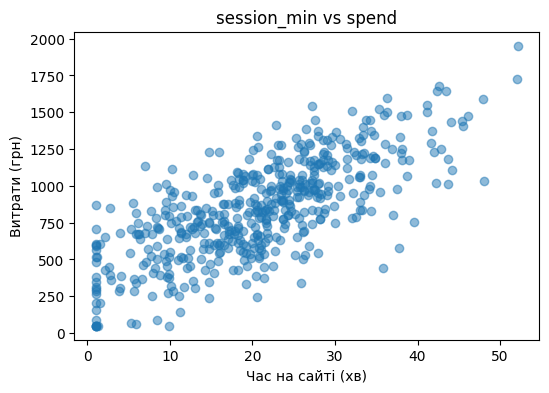

In [ ]:
# Завдання 12:
r, p_value = stats.pearsonr(df['session_min'], df['spend'])
print(f'Коефіцієнт кореляції r: {r:.4f}')
print(f'p-значення: {p_value:.4e}')

plt.figure(figsize=(6, 4))
plt.scatter(df['session_min'], df['spend'], alpha=0.5)
plt.xlabel('Час на сайті (хв)')
plt.ylabel('Витрати (грн)')
plt.title('session_min vs spend')
plt.show()


#### 💬 Інтерпретація 10

Опишіть звʼязок: він прямий чи зворотний? Сильний чи слабкий? Значущий? І найголовніше: чи можна стверджувати, що довший час на сайті СПРИЧИНЯЄ більші витрати? Поясніть свою думку.

*(Напишіть відповідь у наступній клітинці. Двічі клацніть, щоб редагувати.)*

**Ваша відповідь:**

*Кореляція між часом на сайті та витратами: r = 0.732, p ≈ 4.05×10⁻⁸⁵.

Зв'язок прямий (r > 0): чим більше часу клієнт проводить на сайті, тим більше він в середньому витрачає. За силою цей зв'язок можна назвати достатньо сильним (r близьке до 0.7-0.8), і він статистично значущий, бо p-value набагато менше 0.05.

Проте значуща кореляція не означає, що довший час на сайті спричиняє більші витрати. Можливо й навпаки — клієнти, які вже налаштовані купити більше (наприклад, обирають дорожчий товар чи кілька товарів), просто природньо проводять на сайті більше часу через порівняння варіантів і оформлення замовлення. Також може існувати третій фактор (наприклад, рівень заінтересованості клієнта в покупці взагалі), який одночасно впливає і на час на сайті, і на витрати. Кореляція показує лише, що ці дві величини змінюються узгоджено, але не доводить причинно-наслідковий напрямок.*


**Сценарій:** чи повʼязаний вік клієнта (`age`) з його витратами (`spend`)?

#### ✏️ Завдання 13 (код)

Порахуйте кореляцію між `age` та `spend`.

In [ ]:
# Завдання 13:
r, p_value = stats.pearsonr(df['age'], df['spend'])
print(f'Коефіцієнт кореляції r: {r:.4f}')
print(f'p-значення: {p_value:.4f}')


Коефіцієнт кореляції r: -0.0418
p-значення: 0.3508


#### 💬 Інтерпретація 11

Що показала кореляція? Порівняйте цей результат із попереднім (час на сайті vs витрати). У якому випадку звʼязок сильніший і чому це важливо для бізнесу?

*(Напишіть відповідь у наступній клітинці. Двічі клацніть, щоб редагувати.)*

**Ваша відповідь:**

*Кореляція між віком клієнта та витратами: r = -0.042, p = 0.351.

Коефіцієнт r дуже близький до нуля, а p-значення значно більше 0.05 — отже, статистично значущого зв'язку між віком і витратами не виявлено.

Порівнюючи з попереднім результатом (session_min vs spend, r = 0.732, p < 0.001), бачимо, що звʼязок «час на сайті — витрати» набагато сильніший і значущий, тоді як «вік — витрати» практично відсутній. Для бізнесу це важливо: якщо потрібно прогнозувати чи впливати на витрати клієнта, орієнтуватись на час, проведений на сайті, набагато доцільніше, ніж на віковий сегмент клієнта — вік тут просто не є інформативною ознакою.*


---
# Розділ 7. 🔥 Велике завдання: A/B-тест

## 🟦 Теорія: A/B-тестування

Це головне застосування статистики в аналітиці. Ми порівнюємо дві версії (A — контроль, B — варіант) і перевіряємо, чи нова версія справді краща, чи різниця випадкова.

Оскільки результат тут — **категоріальний** (конвертувався / ні), ми використовуємо **хі-квадрат** на таблиці спряженості «група × конверсія».

**Дані `ab_test.csv`:**
- `session_id` — ID сесії
- `group` — A (стара версія) або B (нова версія)
- `converted` — 1 (купив) або 0 (не купив)

Це повноцінне завдання, що імітує реальну роботу аналітика. Виконуйте крок за кроком.

**Крок 1. Дослідіть дані.**

#### ✏️ Завдання 14 (код)

Подивіться на дані `ab`: скільки сесій у групі A і скільки в групі B? (підказка: `value_counts` на `group`)

In [ ]:
# Завдання 14:
group_counts = ab['group'].value_counts()
print('Кількість сесій по групах:')
print(group_counts)


Кількість сесій по групах:
group
A    4000
B    4000
Name: count, dtype: int64


**Крок 2. Порахуйте конверсію кожної групи.**

Конверсія = частка тих, хто купив = середнє значення стовпця `converted` (бо це 0 і 1).

#### ✏️ Завдання 15 (код)

Порахуйте конверсію (середнє `converted`) для групи A і для групи B окремо. (Підказка: `ab.groupby('group')['converted'].mean()`) На скільки відсоткових пунктів відрізняється конверсія?

In [ ]:
# Завдання 15:
conversion = ab.groupby('group')['converted'].mean()
print('Конверсія по групах:')
print(conversion.round(4))

diff_pp = (conversion['B'] - conversion['A']) * 100
print(f'\nРізниця (B - A): {diff_pp:.2f} відсоткових пунктів')


Конверсія по групах:
group
A    0.101
B    0.119
Name: converted, dtype: float64

Різниця (B - A): 1.80 відсоткових пунктів


#### 💬 Інтерпретація 12

Яка група показує вищу конверсію? Чи означає ця різниця в числах, що версія B точно краща? Чому ми НЕ можемо зробити висновок лише з цих чисел, без статистичного тесту?

*(Напишіть відповідь у наступній клітинці. Двічі клацніть, щоб редагувати.)*

**Ваша відповідь:**

*Конверсія групи A склала 10.1%, групи B — 11.9%, тобто група B показує вищу конверсію на 1.8 відсоткового пункту.

Сама по собі ця різниця в числах не означає, що версія B точно краща. Конверсія розрахована на конкретній вибірці сесій, а будь-яка вибірка містить випадкові коливання. Можливо, ми просто отримали трохи більше "вдалих" сесій у групі B випадково, і якби тест повторили, різниця могла би зникнути або навіть розвернутися в інший бік.

Щоб зробити обґрунтований висновок, потрібно перевірити, чи ця різниця достатньо велика, аби не бути випадковістю — для цього і проводять статистичний тест (тут — хі-квадрат), який дає p-значення і дозволяє сказати, наскільки ми можемо довіряти спостереженій різниці.*


**Крок 3. Сформулюйте гіпотези.**

#### 💬 Інтерпретація 13

Запишіть нульову (H₀) та альтернативну (H₁) гіпотези для цього A/B-тесту своїми словами.

*(Напишіть відповідь у наступній клітинці. Двічі клацніть, щоб редагувати.)*

**Ваша відповідь:**

*H₀ (нульова гіпотеза): конверсія в групі A (стара версія) і групі B (нова версія) однакова — версія сайту не впливає на ймовірність покупки, а спостережена різниця в конверсії випадкова.

H₁ (альтернативна гіпотеза): конверсія в групах A і B відрізняється — версія сайту впливає на ймовірність покупки.*


**Крок 4. Проведіть тест.**

#### ✏️ Завдання 16 (код)

Побудуйте таблицю спряженості `group` × `converted` і проведіть тест хі-квадрат. Виведіть таблицю та p-значення.

In [ ]:
# Завдання 16:
ct_ab = pd.crosstab(ab['group'], ab['converted'])
print('Таблиця спряженості (group x converted):')
print(ct_ab)

chi2, p_value, dof, expected = stats.chi2_contingency(ct_ab)
print(f'\nchi2-статистика: {chi2:.4f}')
print(f'p-значення: {p_value:.4f}')
print(f'степені свободи: {dof}')


Таблиця спряженості (group x converted):
converted     0    1
group               
A          3596  404
B          3524  476

chi2-статистика: 6.4364
p-значення: 0.0112
степені свободи: 1


**Крок 5. Висновок.**

#### 💬 Інтерпретація 14

На основі p-значення: чи є різниця між версіями статистично значущою (при α = 0.05)? Який ваш висновок — впроваджувати версію B чи ні? Сформулюйте фінальну рекомендацію для продуктової команди одним абзацом, як справжній аналітик.

*(Напишіть відповідь у наступній клітинці. Двічі клацніть, щоб редагувати.)*

**Ваша відповідь:**

*Тест хі-квадрат для звʼязку версії сайту (group) та конверсії (converted) дав chi2 = 6.436, p = 0.0112.

Оскільки p-value < 0.05 (при α = 0.05), різниця між версіями A і B є статистично значущою — ми відхиляємо нульову гіпотезу про відсутність звʼязку.

Фінальна рекомендація: дані показують статистично значуще зростання конверсії з 10.1% до 11.9% (+1.8 в.п.) при переході на версію B, тому я рекомендую впровадити версію B на всіх користувачів. Водночас варто звернути увагу й на практичну значущість ефекту — абсолютний прирост у 1.8 в.п. на масштабі 8000 сесій трансформується у відчутну кількість додаткових покупок, але перед повним розгортанням варто оцінити вартість впровадження зміни та, за можливості, переконатися, що ефект стабільний у часі (наприклад, перевіривши результат на додатковому періоді спостережень), щоб виключити сезонні чи тимчасові фактори.*


---
# Розділ 8. 🧠 Обери тест сам

## 🟦 Теорія

Найважливіша навичка аналітика — не запам'ятати функції, а вміти **обрати правильний тест** для задачі. У цьому розділі ми НЕ підказуємо тест — ви маєте визначити його самі.

**Алгоритм вибору:**
1. Який тип даних на виході? (числовий чи категоріальний)
2. Скільки груп / змінних порівнюємо?
3. Це незалежні групи чи «до/після» в тих самих об'єктів?

Кожне завдання: спочатку у клітинці інтерпретації **назвіть тест і поясніть вибір**, потім напишіть код.

**Задача A.** Компанія хоче знати, чи відрізняється середній вік клієнтів у трьох каналах залучення.

#### 💬 Інтерпретація 15

Який тест ви оберете і чому? (Спочатку відповідь, потім код нижче.)

*(Напишіть відповідь у наступній клітинці. Двічі клацніть, щоб редагувати.)*

**Ваша відповідь:**

*Обираю ANOVA (дисперсійний аналіз). Вихідна змінна — вік — числова, а порівнюємо середній вік у ТРЬОХ незалежних групах (трьох каналах залучення). Коли потрібно порівняти середні трьох і більше незалежних груп, правильний тест — саме ANOVA (а не серія парних t-тестів, через накопичення помилки I роду).*


#### ✏️ Завдання 17 (код)

Проведіть обраний тест для задачі A (вік за каналами).

In [ ]:
# Завдання 17:
print('Середній вік по каналах:')
print(df.groupby('channel')['age'].mean().round(2))

groups = [g['age'].dropna().values for _, g in df.groupby('channel')]
f_stat, p_value = stats.f_oneway(*groups)

print(f'\nF-статистика: {f_stat:.4f}')
print(f'p-значення: {p_value:.4f}')


Середній вік по каналах:
channel
Органіка     34.35
Реклама      35.43
Соцмережі    34.21
Name: age, dtype: float64

F-статистика: 0.5989
p-значення: 0.5498


#### 💬 Інтерпретація 16

Що показав результат? Сформулюйте висновок.

*(Напишіть відповідь у наступній клітинці. Двічі клацніть, щоб редагувати.)*

**Ваша відповідь:**

*Середній вік по каналах майже однаковий: Органіка — 34.35, Реклама — 35.43, Соцмережі — 34.21 років. ANOVA дала F = 0.599, p = 0.550 (значно більше 0.05).

Ми не відхиляємо нульову гіпотезу: статистично значущої різниці у середньому віці клієнтів між каналами залучення немає. Тобто канали залучення не повʼязані з віковим профілем клієнтів — усі три канали залучають клієнтів приблизно одного й того ж віку.*


**Задача B.** Маркетолог стверджує, що середні витрати клієнтів дорівнюють 900 грн.

#### 💬 Інтерпретація 17

Який тест підходить і чому?

*(Напишіть відповідь у наступній клітинці. Двічі клацніть, щоб редагувати.)*

**Ваша відповідь:**

*Обираю одновибірковий t-тест. У нас одна група числових даних (витрати клієнтів), і ми порівнюємо її середнє з одним фіксованим, наперед заданим числом (900 грн), яке заявив маркетолог. Це класичний сценарій для `ttest_1samp`.*


#### ✏️ Завдання 18 (код)

Проведіть обраний тест для задачі B.

In [ ]:
# Завдання 18:
mean_spend = df['spend'].mean()

t_stat, p_value = stats.ttest_1samp(df['spend'].dropna(), popmean=900)

print(f'Середні витрати: {mean_spend:.2f}')
print(f't-статистика: {t_stat:.4f}')
print(f'p-значення: {p_value:.4e}')


Середні витрати: 845.02
t-статистика: -3.6870
p-значення: 2.5179e-04


#### 💬 Інтерпретація 18

Висновок: маркетолог має рацію?

*(Напишіть відповідь у наступній клітинці. Двічі клацніть, щоб редагувати.)*

**Ваша відповідь:**

*Фактичні середні витрати становлять 845.02 грн, а отримане p-значення ≈ 0.00025 (значно менше 0.05).

Ми відхиляємо нульову гіпотезу: середні витрати клієнтів статистично значуще відрізняються від заявлених маркетологом 900 грн. Маркетолог НЕ має рації — фактичне середнє (845.02 грн) суттєво нижче за заявлене значення, і ця різниця не є випадковою.*


**Задача C.** Чи повʼязана країна клієнта (`country`) з пристроєм (`device`)?

#### 💬 Інтерпретація 19

Який тест підходить і чому?

*(Напишіть відповідь у наступній клітинці. Двічі клацніть, щоб редагувати.)*

**Ваша відповідь:**

*Обираю тест хі-квадрат. Обидві змінні — країна та пристрій — категоріальні, і нас цікавить, чи є звʼязок (асоціація) між ними на основі частот у таблиці спряженості. Це класичний випадок для `chi2_contingency`.*


#### ✏️ Завдання 19 (код)

Проведіть обраний тест для задачі C.

In [ ]:
# Завдання 19:
ct_country_device = pd.crosstab(df['country'], df['device'])
print('Таблиця спряженості (country x device):')
print(ct_country_device)

chi2, p_value, dof, expected = stats.chi2_contingency(ct_country_device)
print(f'\nchi2-статистика: {chi2:.4f}')
print(f'p-значення: {p_value:.4f}')
print(f'степені свободи: {dof}')


Таблиця спряженості (country x device):
device     Desktop  Mobile
country                   
Німеччина       46      63
Польща          49      82
Україна         94     166

chi2-статистика: 1.2067
p-значення: 0.5470
степені свободи: 2


#### 💬 Інтерпретація 20

Висновок про звʼязок країни та пристрою.

*(Напишіть відповідь у наступній клітинці. Двічі клацніть, щоб редагувати.)*

**Ваша відповідь:**

*Тест хі-квадрат для звʼязку країни та пристрою дав chi2 = 1.207, p = 0.547 (значно більше 0.05).

Ми не відхиляємо нульову гіпотезу: статистично значущого звʼязку між країною клієнта та вибором пристрою не виявлено. Розподіл Mobile/Desktop приблизно однаковий у всіх трьох країнах.*


**Задача D.** Чи повʼязаний вік клієнта з часом, який він проводить на сайті?

#### 💬 Інтерпретація 21

Який тест підходить і чому?

*(Напишіть відповідь у наступній клітинці. Двічі клацніть, щоб редагувати.)*

**Ваша відповідь:**

*Обираю кореляцію Пірсона. Обидві змінні — вік та час на сайті — числові, і нас цікавить сила та напрямок лінійного звʼязку між ними, для чого використовується `pearsonr`.*


#### ✏️ Завдання 20 (код)

Проведіть обраний тест для задачі D.

In [ ]:
# Завдання 20:
r, p_value = stats.pearsonr(df['age'], df['session_min'])
print(f'Коефіцієнт кореляції r: {r:.4f}')
print(f'p-значення: {p_value:.4f}')


Коефіцієнт кореляції r: -0.0119
p-значення: 0.7898


#### 💬 Інтерпретація 22

Опишіть звʼязок (напрямок, сила, значущість).

*(Напишіть відповідь у наступній клітинці. Двічі клацніть, щоб редагувати.)*

**Ваша відповідь:**

*Кореляція між віком клієнта та часом на сайті: r = -0.012, p = 0.790.

Коефіцієнт r практично нульовий (слабкий зворотний напрямок, але настільки малий, що про напрямок говорити не варто), а p-значення значно більше 0.05. Це означає, що статистично значущого звʼязку між віком клієнта та часом, проведеним на сайті, не виявлено — вік не повʼязаний із тривалістю сесії.*


---
# 🎉 Вітаємо із завершенням!

Ви пройшли повний цикл роботи аналітика зі статистичними тестами:

- ✅ Одновибірковий, двовибірковий та парний t-тести
- ✅ ANOVA для 3+ груп
- ✅ Хі-квадрат для категоріальних даних
- ✅ Кореляція для числових змінних
- ✅ Повноцінний A/B-тест
- ✅ Самостійний вибір тесту під задачу

## Головне, що варто винести

1. **Вибір тесту** важливіший за код. Завжди питайте: який тип даних? скільки груп? незалежні чи парні?
2. **p-значення** саме по собі — це лише число. Цінність створює ваша **інтерпретація**.
3. **Контекст вирішує:** памʼятайте про розмір ефекту, практичну значущість і те, що кореляція ≠ причинність.

## Питання для самоперевірки
- Чи можете ви пояснити різницю між парним і двовибірковим t-тестом?
- Чому не можна замінити одну ANOVA трьома t-тестами?
- Що означає «не відхилили H₀» — чи це те саме, що «довели, що ефекту немає»?

Якщо на всі три питання ви відповідаєте впевнено — ви добре засвоїли тему. Так тримати! 📊
